# Macrocircuits

***Macrocircuits: Leveraging neural architectural priors and modularity in embodied agents***

**By Neuromatch Academy**

*This notebook uses code from the following GitHub repository:* [ncap](https://github.com/nikhilxb/ncap) by Nikhil X. Bhattasali and Anthony M. Zador and Tatiana A. Engel.


**Tutorial links**

This particular project connects a couple of distinct ideas explored throughout the course. Firstly, the innate ability to learn a certain set of actions quickly is the main topic of [Tutorial 4](https://neuroai.neuromatch.io/tutorials/W2D4_Macrolearning/student/W2D4_Tutorial4.html) for **W2D4** on biological meta-learning. The focus comes with the observation that the brain is not of a generic architecture but is a highly structured and optimized hierarchy of modules, the importance of which is highlighted in [Tutorial 3](https://neuroai.neuromatch.io/tutorials/W2D1_Macrocircuits/student/W2D1_Tutorial3.html) for **W2D1**, forming inductive bias for efficient motor control. The default model for the agent used here is already known Actor-Critic; you had the opportunity to observe in already mentioned tutorials as well as in [Tutorial 3](https://neuroai.neuromatch.io/tutorials/W1D2_ComparingTasks/student/W1D2_Tutorial3.html) for **W1D2**.

---
## Scetion 0: Initial setup

**Imports and Utility Functions**

In [1]:
#@title Importing Libraries
import sys
from pathlib import Path

# This notebook only orchestrates. Every function and class it calls lives in the
# `macrocircuits` package under src/ -- read or edit it there.
SRC = str(Path.cwd().parent / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import numpy as np
import matplotlib.pyplot as plt
from dm_control import suite

# Importing macrocircuits also registers the `swim` and `swim_12_links` tasks with
# the dm_control swimmer suite, which is what lets suite.load() find them below.
from macrocircuits import display_video, ensure_tonic, render, test_dm_control

# Clone neuromatch/tonic next to this notebook (once) and put it on the import path.
# It has to run before the tonic-backed imports below (training, models); see
# src/macrocircuits/tonic_setup.py for why tonic isn't a pip install.
ensure_tonic()

# The Swim task rewards swimming forward at _SWIM_SPEED and hides the target the
# stock dm_control swimmer chases.
from macrocircuits.envs import Swim, swim  # See src/macrocircuits/envs.py.
from macrocircuits.training import play_model, train  # See src/macrocircuits/training.py.
from macrocircuits.models import (  # See src/macrocircuits/models.py.
    d4pg_swimmer_model,
    ppo_mlp_model,
    ppo_swimmer_model,
)
from macrocircuits.constraints import (  # See src/macrocircuits/constraints.py.
    excitatory,
    excitatory_constant,
    excitatory_uniform,
    graded,
    inhibitory,
    inhibitory_constant,
    inhibitory_uniform,
    unsigned,
    unsigned_constant,
    unsigned_uniform,
)
from macrocircuits.ncap import SwimmerActor, SwimmerModule  # See src/macrocircuits/ncap.py.
from macrocircuits.plotting import (  # See src/macrocircuits/plotting.py.
    draw_network,
    plot_performance,
    show_paper_figure,
)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


---
## Section 1: Exploring the DeepMind Swimmer

### 1.1 Create a basic swim task for the swimmer environment


First, we'll initialize a basic swimmer agent consisting of 6 links. Each agent requires a defined task and its corresponding reward function. In this instance, we've designed a swim forward task that involves the agent swimming forward in any direction.

The environment is flexible, allowing for modifications to introduce additional tasks such as "swim only in the x-direction" or "move towards a ball."

### 1.2 Vizualizing an agent that takes random actions in the environment

Let's visualize the environment by executing a sequence of random actions on a swimmer agent. This involves applying random actions over a series of steps and compiling the rendered frames into a video to visualize the agent's behavior.

In [2]:
env = suite.load('swimmer', 'swim', task_kwargs={'random': 1})

In [3]:
test_dm_control(env)

### 1.3 Swimmer Agent API

The observation space consists of 25 total dimensions, combining joint positions and body velocities, while the action space involves 5 dimensions representing normalized joint forces.


**Observation Space**: 4k - 1 total (k = 6 $\rightarrow$ 23)

- k - 1: joint positions $q_i \in [-\pi, \pi]$ (`joints`)
- 3k: link linear velocities $vx_i, vy_i \in \mathbb{R}$ and rotational velocity $wz_i \in \mathbb{R}$ (`body_velocities`)

In [4]:
env.observation_spec()

OrderedDict([('joints',
              Array(shape=(5,), dtype=dtype('float64'), name='joints')),
             ('body_velocities',
              Array(shape=(18,), dtype=dtype('float64'), name='body_velocities'))])

**Action Space**: k - 1 total (k = 6 $\rightarrow$ 5)

- k - 1: joint normalized force $\ddot{q}_i \in [-1, 1]$

In [5]:
env.action_spec()

BoundedArray(shape=(5,), dtype=dtype('float64'), name=None, minimum=[-1. -1. -1. -1. -1.], maximum=[1. 1. 1. 1. 1.])

### 1.4 Example of simple modification to the agent


Let's make a new swimmer agent with 12 links instead of 6, introducing complexity. Additionally, we have the flexibility to adjust various other parameters.

In [6]:
# swim_12_links is defined next to `swim` in src/macrocircuits/envs.py -- same task,
# same Swim class, only n_links changes.
env = suite.load('swimmer', 'swim_12_links', task_kwargs={'random': 1})
test_dm_control(env)

Using the API provided by Deepmind we can create any kind of changes to the agent and the environment.

Try to make the following changes to make yourself more familiar with the swimmer.

*   ***Adding a target (like a ball) to this environment at some x distance away from the agent.***
*   ***Increasing the viscosity of the environment.***



Have a look at the following links to see what kind of assets you will need to modify to make these changes.


*   [swimmer.py](https://github.com/google-deepmind/dm_control/blob/main/dm_control/suite/swimmer.py)
*   [swimmer.xml](https://github.com/google-deepmind/dm_control/blob/main/dm_control/suite/swimmer.xml)




In [7]:
# Adding a target (a "ball"): the swim_to_ball task keeps the ball the stock swimmer
# provides (which the plain `swim` task hides) visible at a random spot each episode,
# and rewards the swimmer for swimming forward AND for getting its nose near the ball.
# The task lives next to `swim` in src/macrocircuits/envs.py (class SwimToBall).
env = suite.load('swimmer', 'swim_to_ball', task_kwargs={'random': 1})
test_dm_control(env)

---
## Section 2: Training models on the swim task


To train the agents we defined in the previous section, we will utilize standard reinforcement learning (RL) algorithms. For the purposes of this tutorial, we will employ the [tonic_rl](https://github.com/fabiopardo/tonic) library, which provides a robust framework for training RL agents.

### Section 2.1 Defining the train function

First we defined a general training function to train any agent on any given environment with a variety of available algorithms. Given below are some of the parameter definitions of the function. You'll likely want to adjust these parameters to customize the training process for an agent in a specific environment using your chosen algorithm from the tonic library:

* **Header**: Python code required to run before training begins, primarily for importing essential libraries or modules.

* **Agent**: The agent that will undergo training; refer to section 3.2 and 4.2 for definitions of MLP and NCAP respectively.

* **Environment**: The training environment for the agent. Ensure it is registered with the DeepMind Control Suite as detailed in section 2.

* **Name**: The experiment's name, which will be utilized for log and model saving purposes.

* **Trainer**: The trainer instance selected for use. It allows the configuration of the training steps, model saving frequency, and other training-related parameters.


### Section 2.2 Training MLP model on swim task

Now we are going to define a function for creating an actor-critic model suitable for Proximal Policy Optimization (PPO) using a Multi-Layer Perceptron (MLP) architecture.

Next we call the train function which initiates the training process for the provided agent using the Tonic library. It specifies the components necessary for training, including the model, environment, and training parameters:

**Agent**: A Proximal Policy Optimization (PPO) agent with a custom Multi-Layer Perceptron (MLP) model architecture, configured with 256 units in each of two layers for both the actor and the critic.

**Environment**: The training environment is set to "swimmer-swim" from the Control Suite, a benchmark suite for continuous control tasks.

**Name**: The experiment is named 'mlp_256', which is useful for identifying logs and saved models associated with this training run.

**Trainer**: Specifies the training configuration, including the total number of steps (5e5) and the frequency of saving the model (1e5 steps).


*Note:* The model will checkpoint every 'save_steps' amount of training steps*  




In [8]:
train('import tonic.torch',
      'tonic.torch.agents.PPO(model=ppo_mlp_model(actor_sizes=(256, 256), critic_sizes=(256,256)))',
      'tonic.environments.ControlSuite("swimmer-swim")',
      name = 'mlp_256',
      trainer = 'tonic.Trainer(steps=int(5e5),save_steps=int(1e5))')

c:\Users\Jakob\GitHub\neuromatch_macrocircuits\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Config file saved to data\local\experiments\tonic\swimmer-swim\mlp_256\config.yaml
          Time left:  epoch 0:00:00  total 0:04:06          
actor                                                       
  clip fraction                                        0.139
  entropy                                               1.05
  iterations                                              42
  kl                                                 0.00831
  loss                                               -0.0174
  std                                                  0.692
  stop                                                0.0119
critic                                                      
  iterations                                              80
  loss                                                  2.53
  v                                                     4.83
test                                                        
  action                                                    
  

**Try playing with the parameters of the trainer and the MLP model and see how it affects the performance.**


*   ***How do the actor and the critic model size affect the performance.***
*   ***Consider increasing the number of steps in trainer to train the model for longer.***
*   ***Explore [Tonic library](https://github.com/fabiopardo/tonic) to see what algorithms we can use to train our agents. (D4PG is usually faster than PPO)***

In [9]:
# add your code

### Section 2.3 Function to run any model on the environment and generate video

Here we have defined a function that will generate the videos of the agent using the input model. The function requires path to the checkpoint folder and the environment you wanna run the trained model on.

In [10]:
play_model('data/local/experiments/tonic/swimmer-swim/mlp_256')


Loading weights from data/local/experiments/tonic/swimmer-swim/mlp_256\checkpoints\step_500000.pt


c:\Users\Jakob\GitHub\neuromatch_macrocircuits\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Reward for the run:  968.0148


Try testing the model on a modification of the enviroment it was trained on.


*   ***Train on basic swim task and test on a environment with higher viscosity.***
*   ***Can we train on the basic 6 link swimmer and test on a larger 12 link swimmer?***
* ***Train the model for a bit on the modified environment and see how quickly the model can adapt to the new environment.***




In [11]:
# add your code

---
## Section 3: NCAP

Let's take a look at NCAP a model that was inspired from the C. elegans motor circuit.
Our hope with using such models is that they would already have really good priors which should lead to much better transfer, faster learning curves and possibly really good innate performance (zero shot performance).

### 3.1 NCAP classes

Now we are going to define ***SwimmerModule*** (NCAP model) and ***SwimmerActor*** (wrapper around NCAP model to make it compatible with tonic) classes.



  

#### Section 3.1.1 Defining the constraints

***Can you think of more kinds of weight initializations and constraints that might be useful for the swimmer agent?***

#### Section 3.1.2: Defining the ***SwimmerModule***

The ***SwimmerModule*** class represents the neural network module inspired by the C. elegans neural circuitry, designed for controlling a robotic swimmer with specific architectural priors, such as proprioception and oscillatory movement patterns.

#### Section 3.1.3: Defining the ***SwimmerActor*** wrapper


The ***SwimmerActor*** class acts as a wrapper around the ***SwimmerModule***, managing high-level control signals and observations coming from the environment and passing them to the ***SwimmerModule*** in a suitable format. This class is basically responsible for making the SwimmerModule compatible with the tonic library. If you wish to use any other library to try a algorithm not present in tonic you have to write a new wrapper to make ***SwimmerModule*** compatible with that library.

### 3.2: Train NCAP

We will now define functions akin to those for MLP we defined in Section 3.2, but tailored for the SwimmerActor model.
  


In [12]:
train('import tonic.torch',
      # 'tonic.torch.agents.D4PG(model=d4pg_swimmer_model(n_joints=5,critic_sizes=(128,128)))',
      'tonic.torch.agents.PPO(model=ppo_swimmer_model(n_joints=5,critic_sizes=(256,256)))',
  'tonic.environments.ControlSuite("swimmer-swim",time_feature=True)',
  name = 'ncap_ppo',
  trainer = 'tonic.Trainer(steps=int(1e5),save_steps=int(5e4))')

c:\Users\Jakob\GitHub\neuromatch_macrocircuits\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Config file saved to data\local\experiments\tonic\swimmer-swim\ncap_ppo\config.yaml
          Time left:  epoch 0:00:00  total 0:01:00          
actor                                                       
  clip fraction                                       0.0123
  entropy                                             -0.884
  iterations                                              80
  kl                                                 0.00306
  loss                                             -0.000799
  std                                                    0.1
  stop                                                     0
critic                                                      
  iterations                                              80
  loss                                                  51.3
  v                                                     33.2
test                                                        
  action                                                    
 

Let's visualize the trained NCAP agent in the environment.

In [13]:
play_model('data/local/experiments/tonic/swimmer-swim/ncap_ppo')


Loading weights from data/local/experiments/tonic/swimmer-swim/ncap_ppo\checkpoints\step_100000.pt
Reward for the run:  802.7773


***This architecture was designed using the C. elegans motor circuit that can swim right at birth i.e it should already have really good priors. Can you try visualizing an agent with an untrained NCAP model. Can it swim?***

### 3.3 Plot perfomance

Now we are going to visualize performance of our model

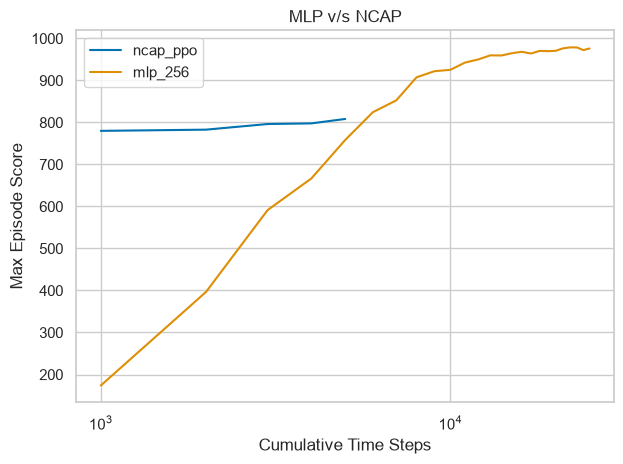

In [ ]:
# rerun this cell if it displays moret than the graphs
%matplotlib inline
fig, ax = plt.subplots()

#Replace the paths with the path to models you trained to plot their performance.
paths = [
    'data/local/experiments/tonic/swimmer-swim/ncap_ppo',
    'data/local/experiments/tonic/swimmer-swim/mlp_256'
]
plot_performance(paths, ax=ax, title='MLP v/s NCAP')
plt.tight_layout()
plt.show()



* ***Compare the performance and learning curve of NCAP to MLP for the basic swimmer agent.***
* ***Try testing the model on a modification of the environment (e.g., the 12-link swimmer) it was trained on.***
* ***What happens if we remove certain weight constraints (e.g., sign constraint) from the NCAP model?***


In [15]:
# add your code

---
## Section 4: Visualizing the sparse network


Given the importance of architectural choices in our project we have provided a function which can visualize the network architecture. This includes the ability to render the NCAP network, representing the C. Elegans connectome.

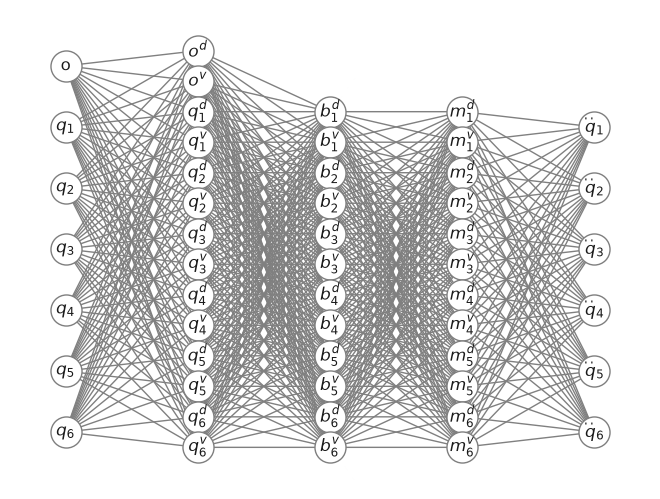

In [16]:
draw_network('MLP', N=6)

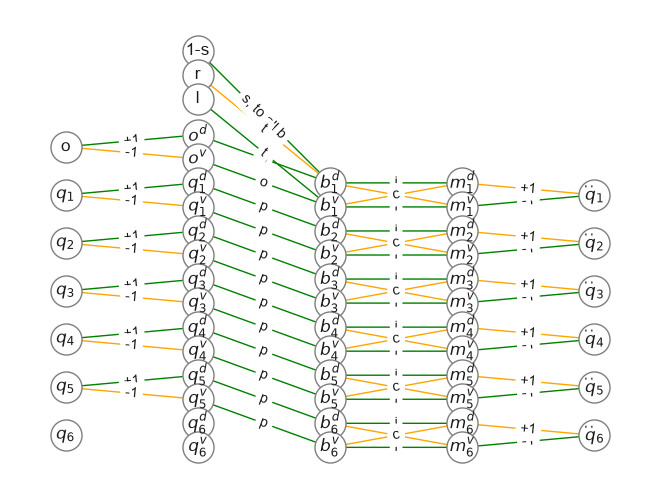

In [17]:
draw_network('NCAP', N=6, include_speed_control=True, include_turn_control=True)

Notice that the NCAP architecture is highly sparse and interpretable as compared to the MLP. Moreover notice that the ncap architecture can be completely embedded within a fully connected MLP of 3 hidden layers and ReLU nonlinearities. This enables us to do a thorough investigation into how specific architectural elements influence both performance and the learning process. By leveraging this capability, we can systematically analyze the impact of the architectural preferences inherent to the model and make better design choices.



*It might be useful to also visualize the network's activity for NCAP. Given it only has 4 learnable parameters it becomes much easier to interpret the network.*

